In [99]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/the-depression-dataset/data/scores.csv
/kaggle/input/the-depression-dataset/data/condition/condition_20.csv
/kaggle/input/the-depression-dataset/data/condition/condition_2.csv
/kaggle/input/the-depression-dataset/data/condition/condition_16.csv
/kaggle/input/the-depression-dataset/data/condition/condition_23.csv
/kaggle/input/the-depression-dataset/data/condition/condition_18.csv
/kaggle/input/the-depression-dataset/data/condition/condition_8.csv
/kaggle/input/the-depression-dataset/data/condition/condition_1.csv
/kaggle/input/the-depression-dataset/data/condition/condition_22.csv
/kaggle/input/the-depression-dataset/data/condition/condition_5.csv
/kaggle/input/the-depression-dataset/data/condition/condition_19.csv
/kaggle/input/the-depression-dataset/data/condition/condition_13.csv
/kaggle/input/the-depression-dataset/data/condition/condition_15.csv
/kaggle/input/the-depression-dataset/data/condition/condition_21.csv
/kaggle/input/the-depression-dataset/data/condition/co

In [100]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [101]:
df=pd.read_csv('/kaggle/input/the-depression-dataset/data/scores.csv')

In [102]:
df.head()

,number,days,gender,age,afftype,melanch,inpatient,edu,marriage,work,madrs1,madrs2
0,condition_1,11,2,35-39,2.0,2.0,2.0,6-10,1.0,2.0,19.0,19.0
1,condition_2,18,2,40-44,1.0,2.0,2.0,6-10,2.0,2.0,24.0,11.0
2,condition_3,13,1,45-49,2.0,2.0,2.0,6-10,2.0,2.0,24.0,25.0
3,condition_4,13,2,25-29,2.0,2.0,2.0,11-15,1.0,1.0,20.0,16.0
4,condition_5,13,2,50-54,2.0,2.0,2.0,11-15,2.0,2.0,26.0,26.0


In [103]:
cols=['days','gender','age','afftype','melanch','inpatient','edu','marriage','work','madrs1','madrs2']
df=df[cols]


In [104]:
df.head()

,days,gender,age,afftype,melanch,inpatient,edu,marriage,work,madrs1,madrs2
0,11,2,35-39,2.0,2.0,2.0,6-10,1.0,2.0,19.0,19.0
1,18,2,40-44,1.0,2.0,2.0,6-10,2.0,2.0,24.0,11.0
2,13,1,45-49,2.0,2.0,2.0,6-10,2.0,2.0,24.0,25.0
3,13,2,25-29,2.0,2.0,2.0,11-15,1.0,1.0,20.0,16.0
4,13,2,50-54,2.0,2.0,2.0,11-15,2.0,2.0,26.0,26.0


In [105]:
df.isnull().sum()

days          0
gender        0
age           0
afftype      32
melanch      35
inpatient    32
edu           2
marriage     32
work         32
madrs1       32
madrs2       32
dtype: int64

In [106]:
df.duplicated().sum()

9

In [107]:
df = df.dropna()

In [109]:
df.isnull().sum()

days         0
gender       0
age          0
afftype      0
melanch      0
inpatient    0
edu          0
marriage     0
work         0
madrs1       0
madrs2       0
dtype: int64

In [110]:
df.duplicated().sum()

0

In [111]:
df = df.drop_duplicates()

In [112]:
df.duplicated().sum()

0

In [113]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20 entries, 0 to 22
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   days       20 non-null     int64  
 1   gender     20 non-null     int64  
 2   age        20 non-null     object 
 3   afftype    20 non-null     float64
 4   melanch    20 non-null     float64
 5   inpatient  20 non-null     float64
 6   edu        20 non-null     object 
 7   marriage   20 non-null     float64
 8   work       20 non-null     float64
 9   madrs1     20 non-null     float64
 10  madrs2     20 non-null     float64
dtypes: float64(7), int64(2), object(2)
memory usage: 1.9+ KB


In [114]:
df.describe()

,days,gender,afftype,melanch,inpatient,marriage,work,madrs1,madrs2
count,20.00000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000
mean,13.10000,1.550000,1.800000,1.950000,1.750000,1.550000,1.900000,22.650000,19.650000
std,2.33734,0.510418,0.523148,0.223607,0.444262,0.510418,0.307794,5.060424,4.659738
min,7.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,13.000000,11.000000
25%,13.00000,1.000000,1.750000,2.000000,1.750000,1.000000,2.000000,18.000000,15.750000
50%,13.00000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,24.000000,20.000000
75%,14.00000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,26.250000,23.250000
max,18.00000,2.000000,3.000000,2.000000,2.000000,2.000000,2.000000,29.000000,28.000000


<Axes: >

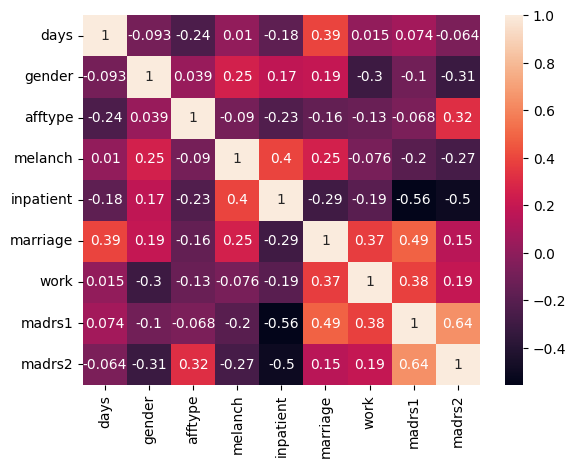

In [115]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

<function matplotlib.pyplot.show(close=None, block=None)>

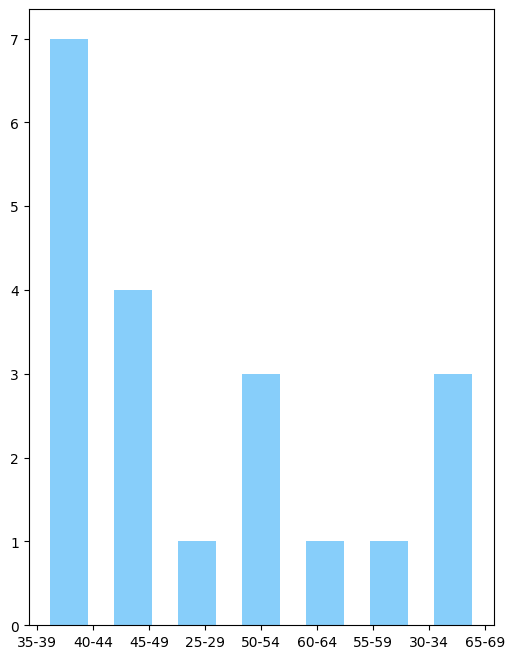

In [116]:
plt.figure(figsize=(6,8))
plt.hist(df.age, bins=7, color='lightskyblue', rwidth=0.6)
plt.show


/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='edu', ylabel='Count'>

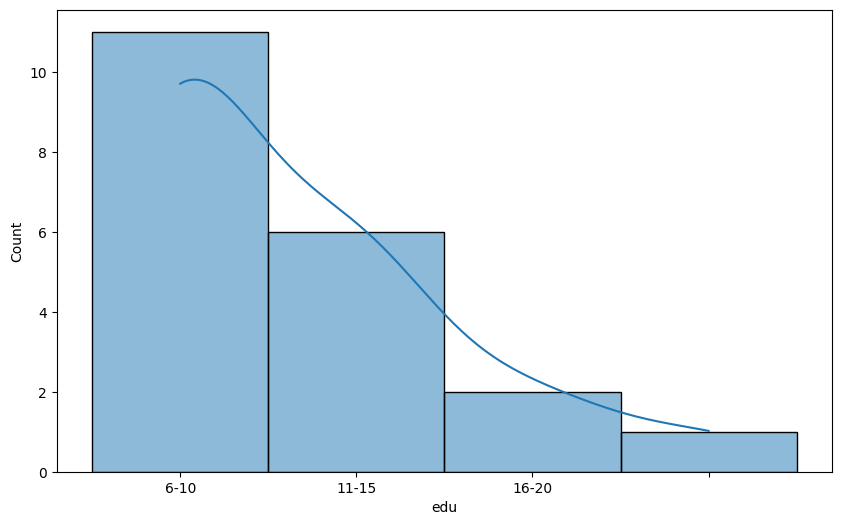

In [118]:
plt.figure(figsize=(10, 6))
sns.histplot(df['edu'], kde=True)

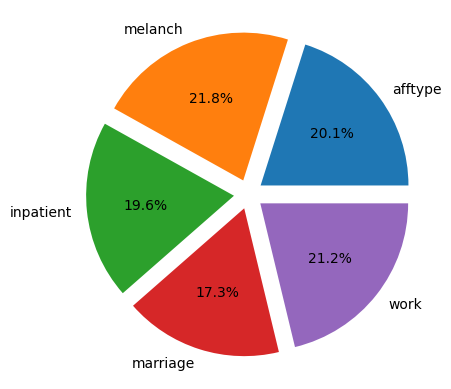

In [125]:
afftype=df.afftype.sum()
melanch=df.melanch.sum()
inpatient=df.inpatient.sum()
marriage=df.marriage.sum()
work=df.work.sum()

minutes=[afftype,melanch,inpatient,marriage,work]
labels=['afftype','melanch','inpatient','marriage','work']
        
plt.pie(minutes, labels=labels, autopct='%1.1f%%', explode=[0.1,0.1,0.1,0.1,0.1])        
plt.show()

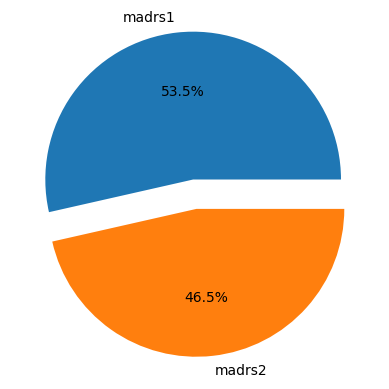

In [126]:
madrs1=df.madrs1.sum()
madrs2=df.madrs2.sum()

minutes=[madrs1,madrs2]
labels=['madrs1','madrs2']

plt.pie(minutes,labels=labels,autopct='%1.1f%%',explode=[0.1,0.1])
plt.show()